# Predicting F1 Pit Stops

## 🏎️ Introduction

Formula 1 pit stop strategy can strongly influence race performance and final standings. Teams must decide the best moment to bring drivers into the pit lane while balancing tire wear, race position, lap timing, and overall strategy.

In this project, the goal is to predict whether a driver will pit on the next lap using data from the Kaggle Playground Series - Season 6 Episode 5 competition.

This project treats the task as a binary classification problem and focuses on:

- Understanding the dataset<br>
- Exploring race and driver patterns<br>
- Engineering meaningful features<br>
- Building machine learning models<br>
- Evaluating performance using appropriate metrics<br>
- Interpreting results in a practical racing context<br>

The notebook is structured as a complete end-to-end machine learning workflow designed for both learning and portfolio presentation.

### Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


### Load the Data

In [2]:
# Load datasets
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv")

# Display shapes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (439140, 16)
Test shape: (188165, 15)
Sample submission shape: (188165, 2)


## 🔍 Initial Data Exploration

Before building any models, it is important to understand the structure of the dataset.

This section focuses on:

- Understanding the available features<br>
- Checking data types<br>
- Identifying missing values<br>
- Reviewing the target variable<br>
- Looking for potential data quality issues<br>

A strong understanding of the dataset helps guide feature engineering and modeling decisions later in the project.

In [3]:
# Preview training data
train_df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
# Dataset information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [5]:
# Numerical summary
train_df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [6]:
# Missing values
missing_values = train_df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [7]:
# Target distribution
train_df["PitNextLap"].value_counts()

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

In [8]:
# Confirm target column
target = "PitNextLap"

train_df[target].value_counts(normalize=True) * 100

PitNextLap
0.0    80.10179
1.0    19.89821
Name: proportion, dtype: float64

### Data Understanding

The training dataset contains 439,140 rows and 16 columns. Each row appears to represent a driver’s lap-level race information, including tire compound, race, year, lap number, stint, tire life, position, lap time, and degradation-related features.

The target variable is `PitNextLap`, which indicates whether the driver will pit on the next lap.

This is a binary classification problem:

- `0`: The driver does not pit on the next lap<br>
- `1`: The driver pits on the next lap<br>

There are no missing values in the training dataset, which means no immediate missing-value imputation is needed.

The target variable is imbalanced. About 80% of the observations belong to class `0`, while about 20% belong to class `1`. This means accuracy alone may not be a reliable evaluation metric because a model could perform well by mostly predicting “no pit”.

Because of this imbalance, evaluation should include metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix.

## 🧹 Data Cleaning

In [9]:
# Clean column names for easier coding
train_df.columns = train_df.columns.str.replace(" ", "_")
train_df.columns = train_df.columns.str.replace("(", "", regex=False)
train_df.columns = train_df.columns.str.replace(")", "", regex=False)

test_df.columns = test_df.columns.str.replace(" ", "_")
test_df.columns = test_df.columns.str.replace("(", "", regex=False)
test_df.columns = test_df.columns.str.replace(")", "", regex=False)

# Check updated column names
train_df.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime_s', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')

### Feature Types

Before exploring the data further, the features can be grouped into categorical and numerical variables.

Categorical features describe labels or groups, such as driver, race, and tire compound.

Numerical features describe measurable values, such as lap number, tire life, position, lap time, degradation, and race progress.

Understanding feature types helps decide how each column should be explored and prepared for modeling.

In [10]:
# Identify categorical and numerical columns
categorical_cols = train_df.select_dtypes(include="object").columns.tolist()
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove target and id from numerical features
numerical_cols = [col for col in numerical_cols if col not in ["id", target]]

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Driver', 'Compound', 'Race']

Numerical columns:
['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


## 📊 Exploratory Data Analysis (EDA)

In [11]:
# Target count
target_counts = train_df[target].value_counts()
target_percentages = train_df[target].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percentages)

Target counts:
PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

Target percentages:
PitNextLap
0.0    80.10179
1.0    19.89821
Name: proportion, dtype: float64


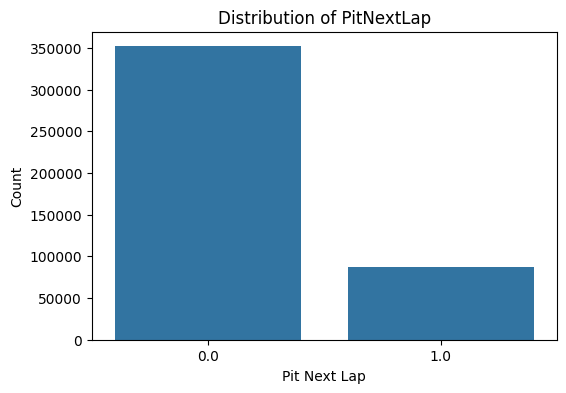

In [12]:
# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x=target)
plt.title("Distribution of PitNextLap")
plt.xlabel("Pit Next Lap")
plt.ylabel("Count")
plt.show()

### Target Variable Analysis

The target variable for this project is `PitNextLap`, which indicates whether a driver will pit on the next lap.

The dataset is moderately imbalanced, with most observations belonging to class `0` (no pit stop on the next lap). Because of this imbalance, evaluation metrics such as precision, recall, F1-score, and ROC-AUC will be more informative than accuracy alone.

In [13]:
# Unique values in categorical columns
for col in categorical_cols:
    print(f"{col}: {train_df[col].nunique()} unique values")
    print(train_df[col].unique()[:10])
    print("-" * 50)

Driver: 887 unique values
['D109' 'D086' 'ZON' 'SPE' 'D019' 'D012' 'D104' 'D082' 'BEL' 'YAM']
--------------------------------------------------
Compound: 5 unique values
['HARD' 'MEDIUM' 'INTERMEDIATE' 'SOFT' 'WET']
--------------------------------------------------
Race: 26 unique values
['Canadian Grand Prix' 'Dutch Grand Prix' 'Austrian Grand Prix'
 'Pre-Season Testing' 'Azerbaijan Grand Prix' 'Saudi Arabian Grand Prix'
 'Belgian Grand Prix' 'United States Grand Prix' 'Italian Grand Prix'
 'Hungarian Grand Prix']
--------------------------------------------------


In [14]:
# PitNextLap rate by tire compound
compound_pit_rate = train_df.groupby("Compound")[target].mean().sort_values(ascending=False)

compound_pit_rate

Compound
HARD            0.327537
SOFT            0.193475
INTERMEDIATE    0.152284
MEDIUM          0.101131
WET             0.025092
Name: PitNextLap, dtype: float64

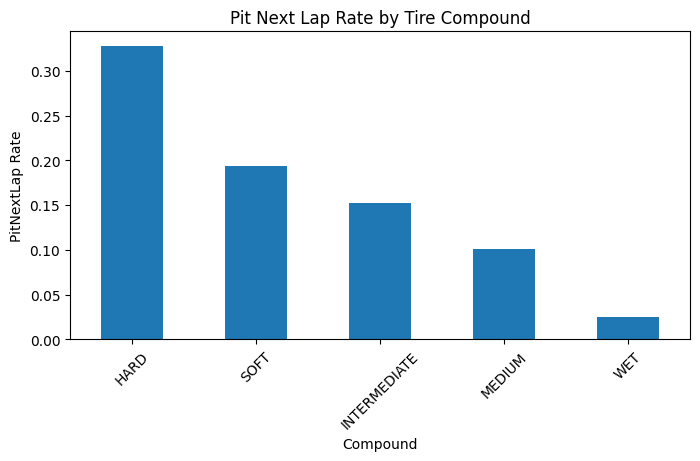

In [15]:
plt.figure(figsize=(8, 4))
compound_pit_rate.plot(kind="bar")
plt.title("Pit Next Lap Rate by Tire Compound")
plt.xlabel("Compound")
plt.ylabel("PitNextLap Rate")
plt.xticks(rotation=45)
plt.show()

In [16]:
# Top drivers by pit next lap rate
driver_pit_rate = train_df.groupby("Driver")[target].mean().sort_values(ascending=False)

driver_pit_rate.head(15)

Driver
VET    0.565460
MSC    0.473239
HAD    0.462069
STR    0.427451
ANT    0.410072
LAT    0.403990
BEA    0.400000
ALO    0.393218
BOR    0.387892
VER    0.356469
RUS    0.356066
OCO    0.354975
LEC    0.344544
GAS    0.340072
HAM    0.337261
Name: PitNextLap, dtype: float64

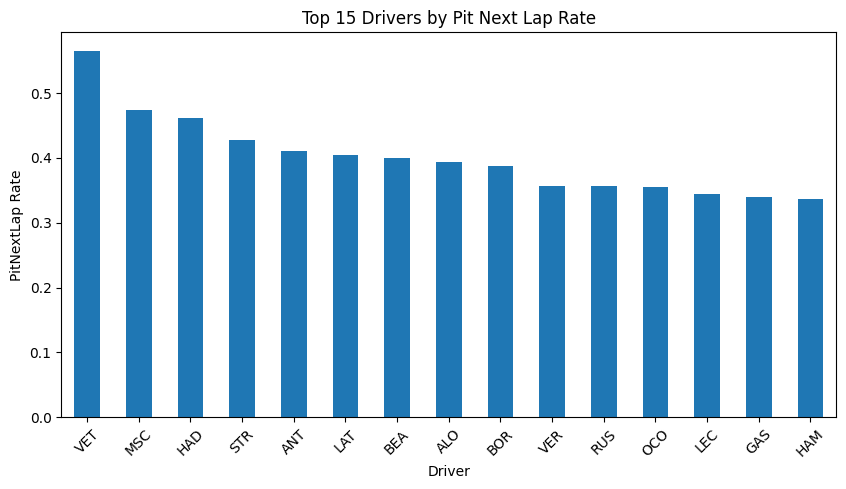

In [17]:
plt.figure(figsize=(10, 5))
driver_pit_rate.head(15).plot(kind="bar")
plt.title("Top 15 Drivers by Pit Next Lap Rate")
plt.xlabel("Driver")
plt.ylabel("PitNextLap Rate")
plt.xticks(rotation=45)
plt.show()

### Categorical Feature Observations

The `Driver` feature contains a large number of unique values, including both recognizable F1 driver abbreviations and synthetic driver identifiers generated as part of the competition dataset.

Although high-cardinality categorical features can increase modeling complexity, driver-specific patterns may still capture useful strategic behavior related to pit timing.

In [18]:
# Summary statistics for numerical columns
train_df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime_s,439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026
RaceProgress,439140.0,0.337661,0.253277,0.012821,0.12987,0.269231,0.513158,1.000


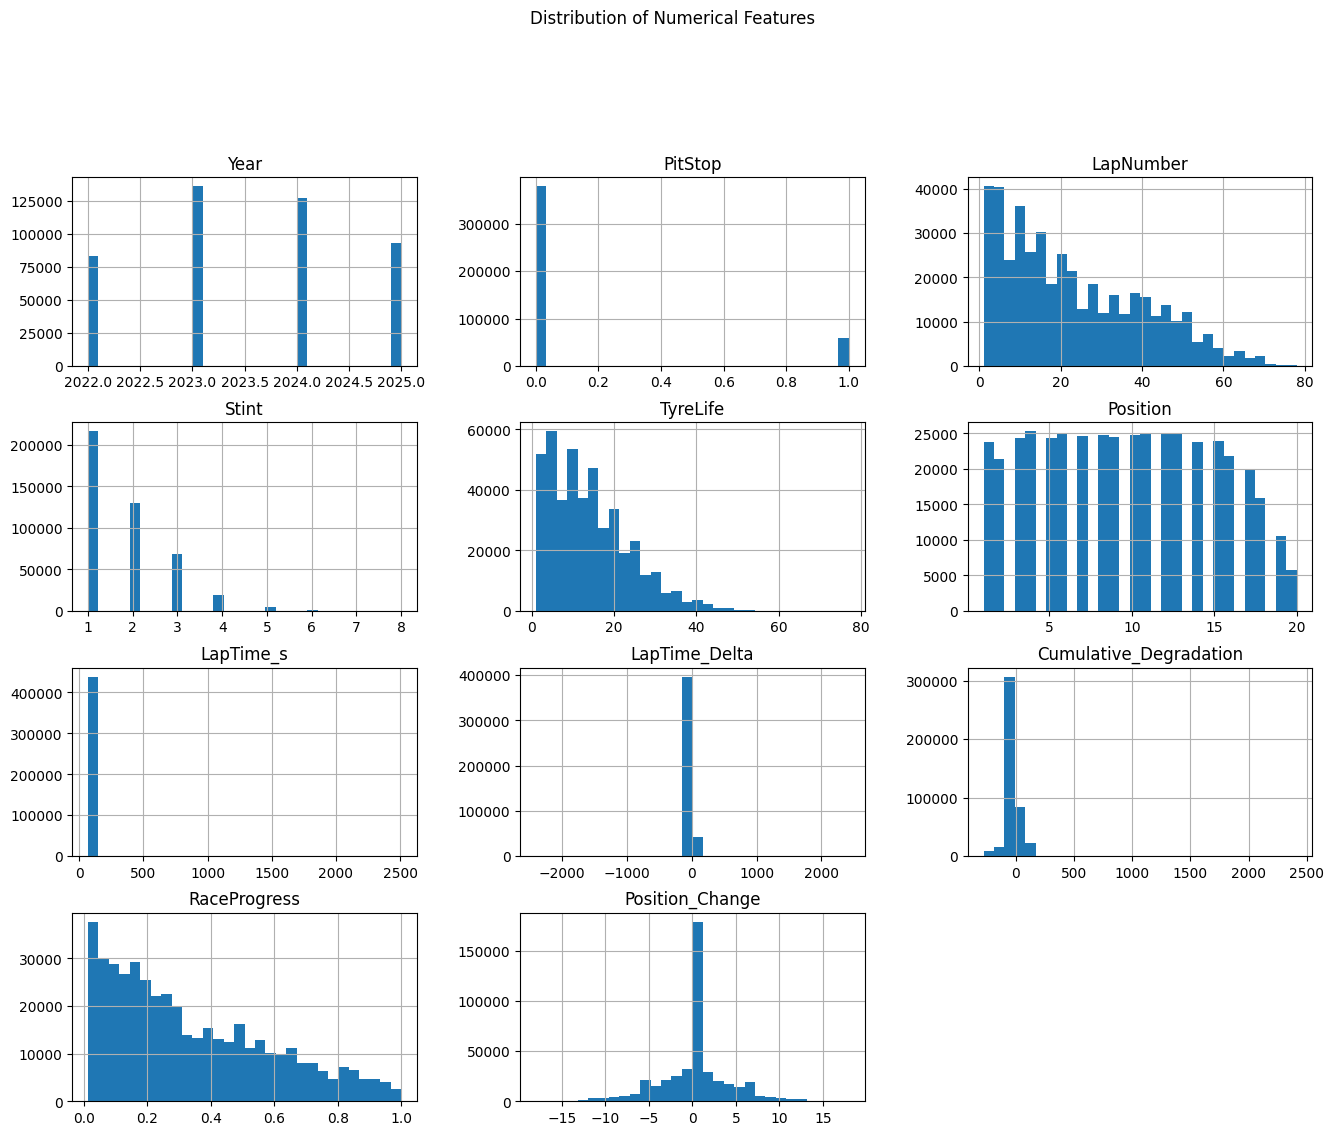

In [19]:
# Histograms for numerical features
train_df[numerical_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of Numerical Features", y=1.02)
plt.show()

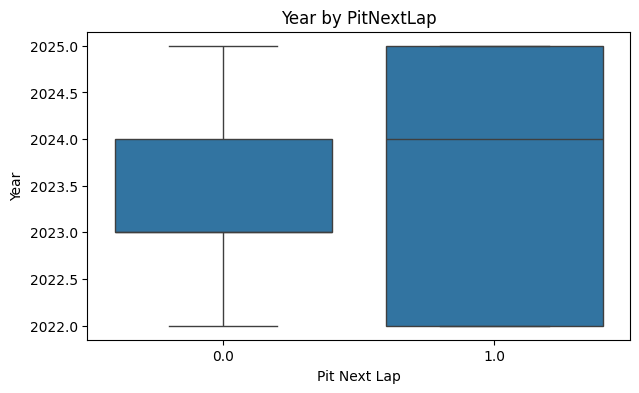

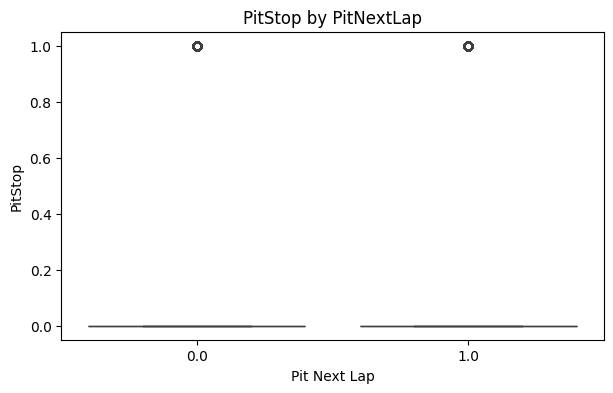

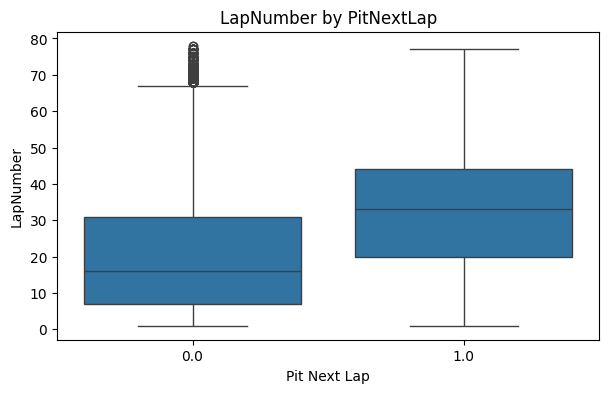

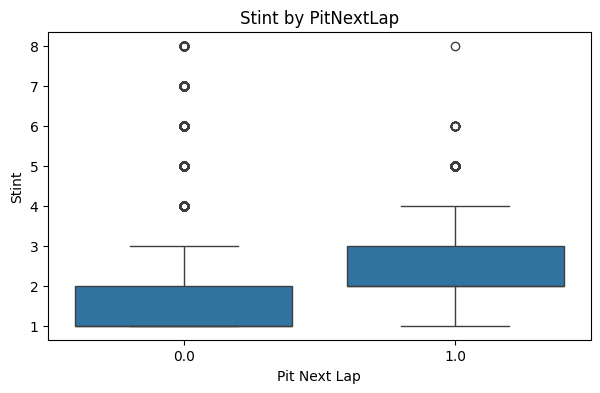

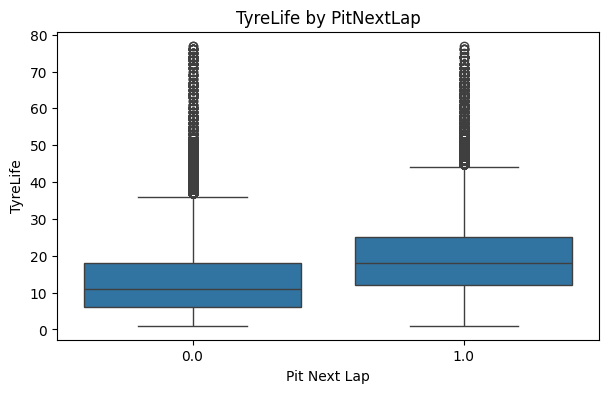

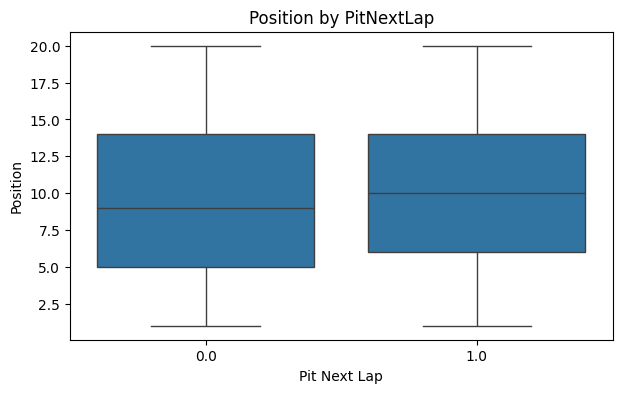

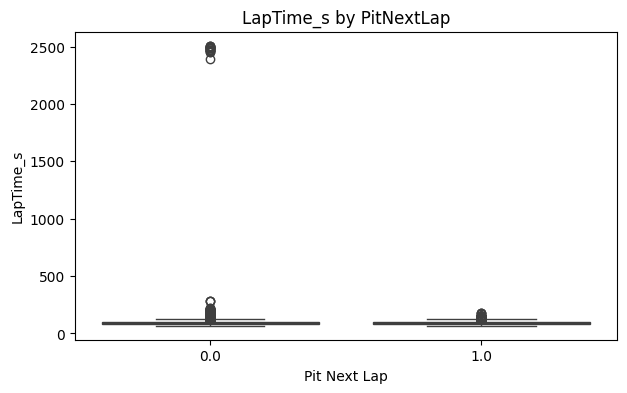

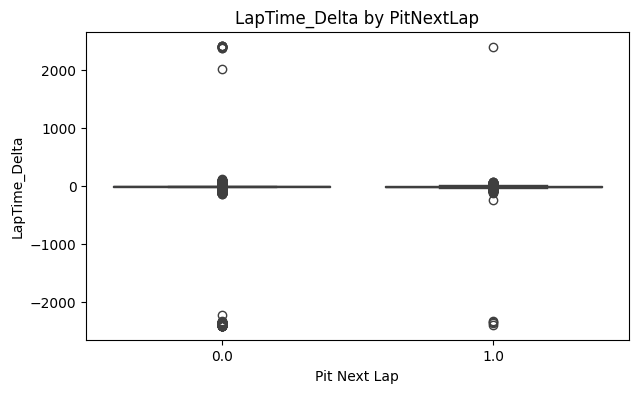

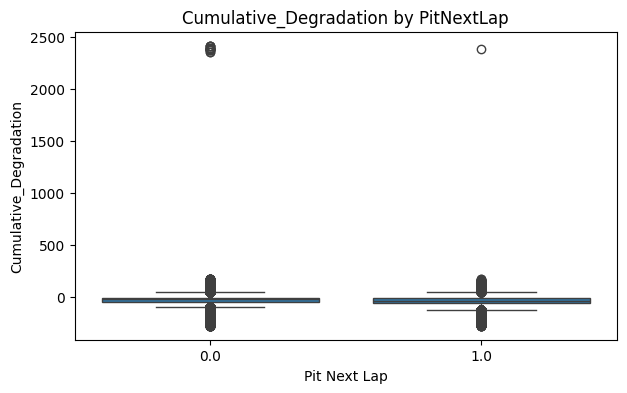

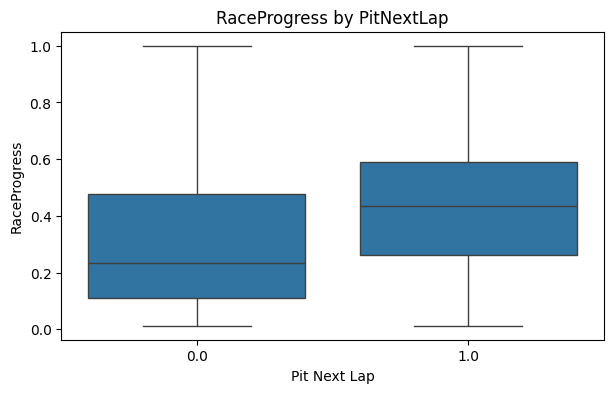

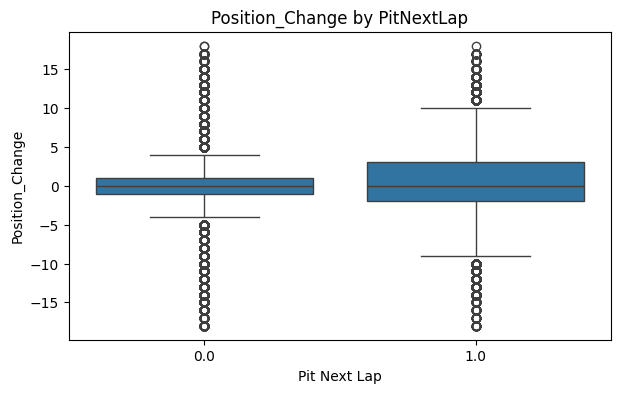

In [20]:
# Compare numerical features by target
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train_df, x=target, y=col)
    plt.title(f"{col} by PitNextLap")
    plt.xlabel("Pit Next Lap")
    plt.ylabel(col)
    plt.show()

### Numerical Feature Observations

Some timing-related features contain extreme values, especially `LapTime_s` and `LapTime_Delta`.

These extreme values may represent incidents such as pit lane activity, crashes, safety cars, or unusually slow laps. Tree-based models may handle these values naturally, but they should still be reviewed during preprocessing and modeling.

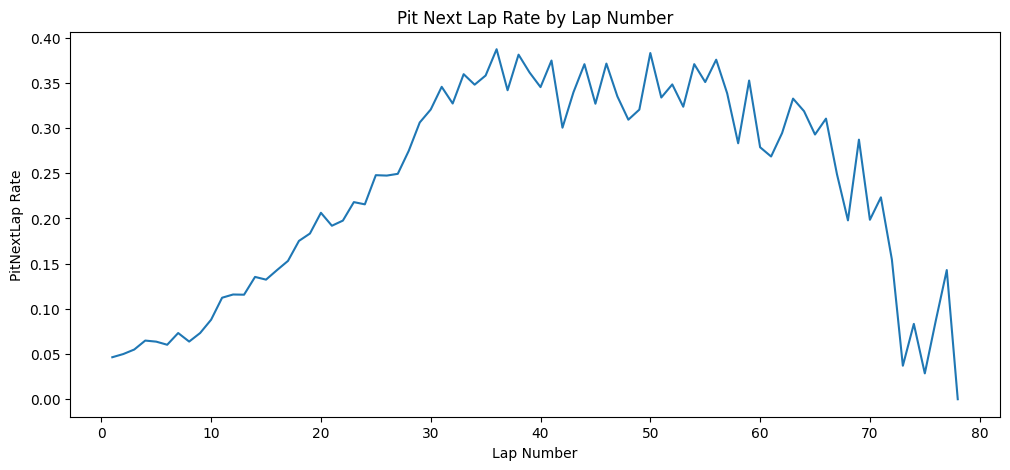

In [21]:
# PitNextLap rate by lap number
lap_pit_rate = train_df.groupby("LapNumber")[target].mean()

plt.figure(figsize=(12, 5))
lap_pit_rate.plot()
plt.title("Pit Next Lap Rate by Lap Number")
plt.xlabel("Lap Number")
plt.ylabel("PitNextLap Rate")
plt.show()

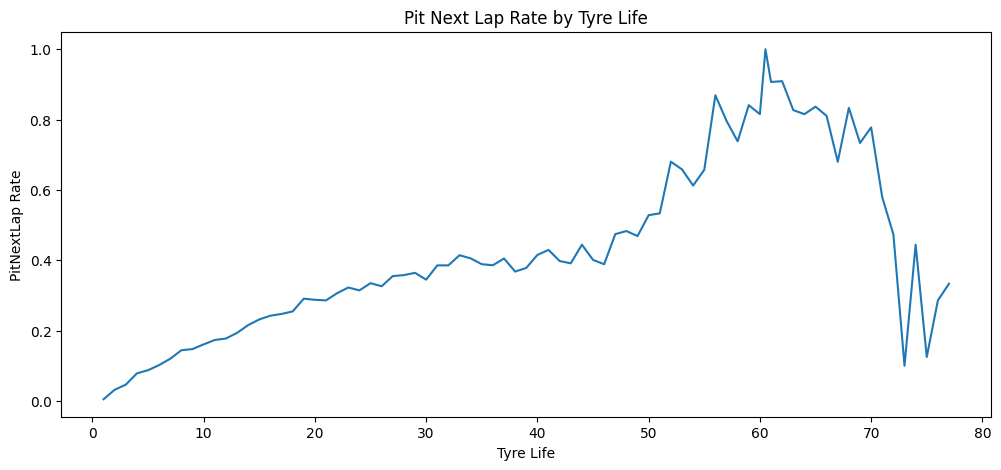

In [22]:
# PitNextLap rate by tyre life
tyre_life_pit_rate = train_df.groupby("TyreLife")[target].mean()

plt.figure(figsize=(12, 5))
tyre_life_pit_rate.plot()
plt.title("Pit Next Lap Rate by Tyre Life")
plt.xlabel("Tyre Life")
plt.ylabel("PitNextLap Rate")
plt.show()

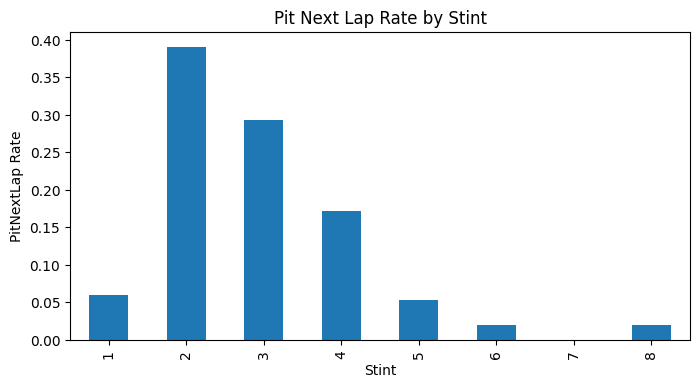

In [23]:
# PitNextLap rate by stint
stint_pit_rate = train_df.groupby("Stint")[target].mean()

plt.figure(figsize=(8, 4))
stint_pit_rate.plot(kind="bar")
plt.title("Pit Next Lap Rate by Stint")
plt.xlabel("Stint")
plt.ylabel("PitNextLap Rate")
plt.show()

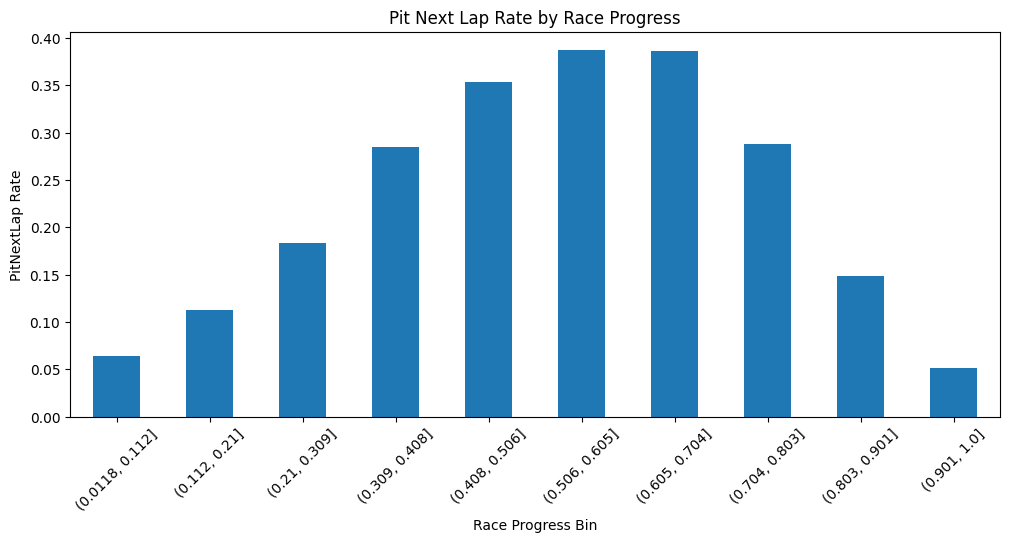

In [24]:
# Create race progress bins
train_df["RaceProgress_Bin"] = pd.cut(
    train_df["RaceProgress"],
    bins=10
)

race_progress_pit_rate = train_df.groupby("RaceProgress_Bin")[target].mean()

plt.figure(figsize=(12, 5))
race_progress_pit_rate.plot(kind="bar")
plt.title("Pit Next Lap Rate by Race Progress")
plt.xlabel("Race Progress Bin")
plt.ylabel("PitNextLap Rate")
plt.xticks(rotation=45)
plt.show()

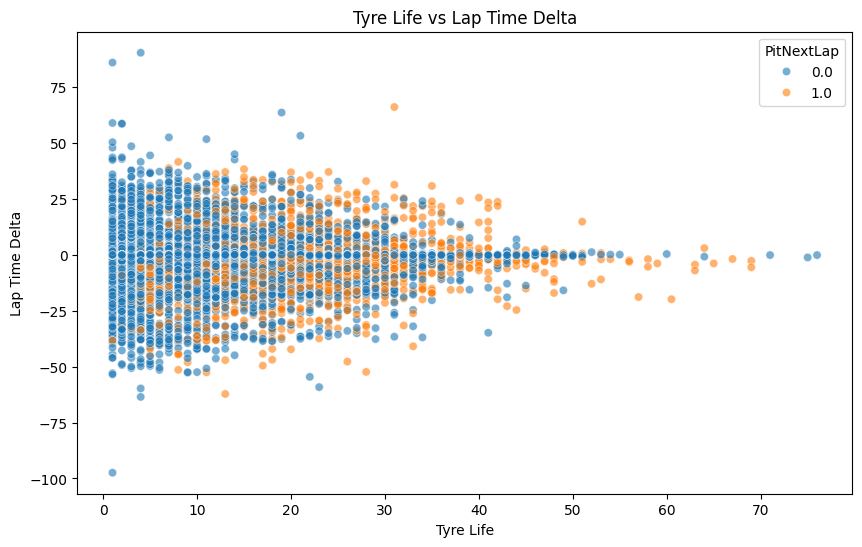

In [25]:
# Remove extreme outliers for visualization only
filtered_df = train_df[
    train_df["LapTime_Delta"].between(-100, 100)
]

# Tyre life vs lap time delta
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=filtered_df.sample(10000, random_state=42),
    x="TyreLife",
    y="LapTime_Delta",
    hue="PitNextLap",
    alpha=0.6
)

plt.title("Tyre Life vs Lap Time Delta")
plt.xlabel("Tyre Life")
plt.ylabel("Lap Time Delta")

plt.show()

### Pit Stop Pattern Observations

The strongest relationship with pit stop probability appears to come from tire usage and race timing features.

As tyre life and lap number increase, the probability of pitting on the next lap also tends to increase. This aligns with real Formula 1 strategy, where older tires become less effective over time and teams are more likely to schedule a pit stop later in a stint.

The visualization also shows that observations associated with upcoming pit stops become more common at higher tyre life values, reinforcing the importance of tire age in pit stop decisions.

Most lap time delta values remain clustered near zero, although there is greater variability at lower tyre life ranges. The spread appears to narrow slightly as tyre life increases.

The two target classes still overlap considerably, indicating that pit stop prediction is not driven by a single feature alone. This suggests that machine learning models will likely benefit from combining multiple race, timing, and tire-related features together.

The later laps and extremely high tyre life values show more volatility in pit stop rates, which is likely caused by smaller sample sizes in those ranges rather than true strategy instability.

In [26]:
# Correlation with target
corr_with_target = train_df[numerical_cols + [target]].corr()[target].sort_values(ascending=False)

corr_with_target

PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
LapTime_Delta            -0.004946
LapTime_s                -0.034096
Cumulative_Degradation   -0.167401
Name: PitNextLap, dtype: float64

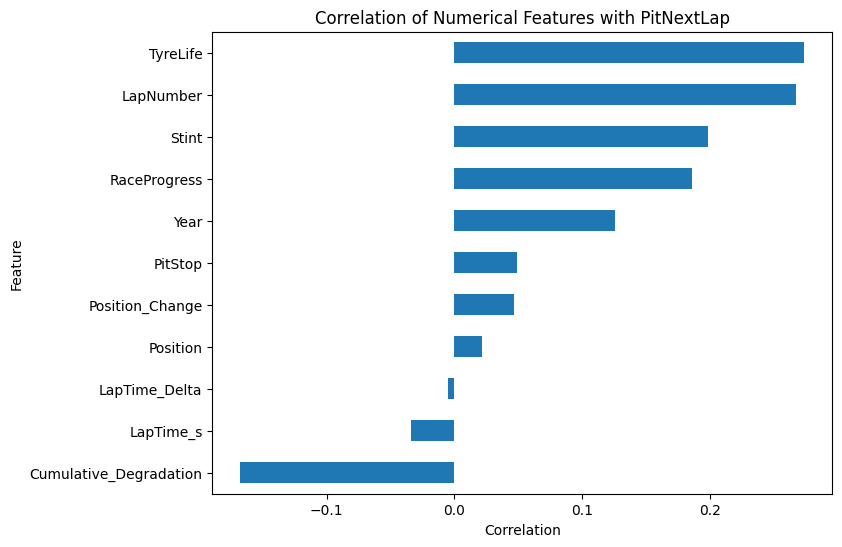

In [27]:
plt.figure(figsize=(8, 6))
corr_with_target.drop(target).sort_values().plot(kind="barh")
plt.title("Correlation of Numerical Features with PitNextLap")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

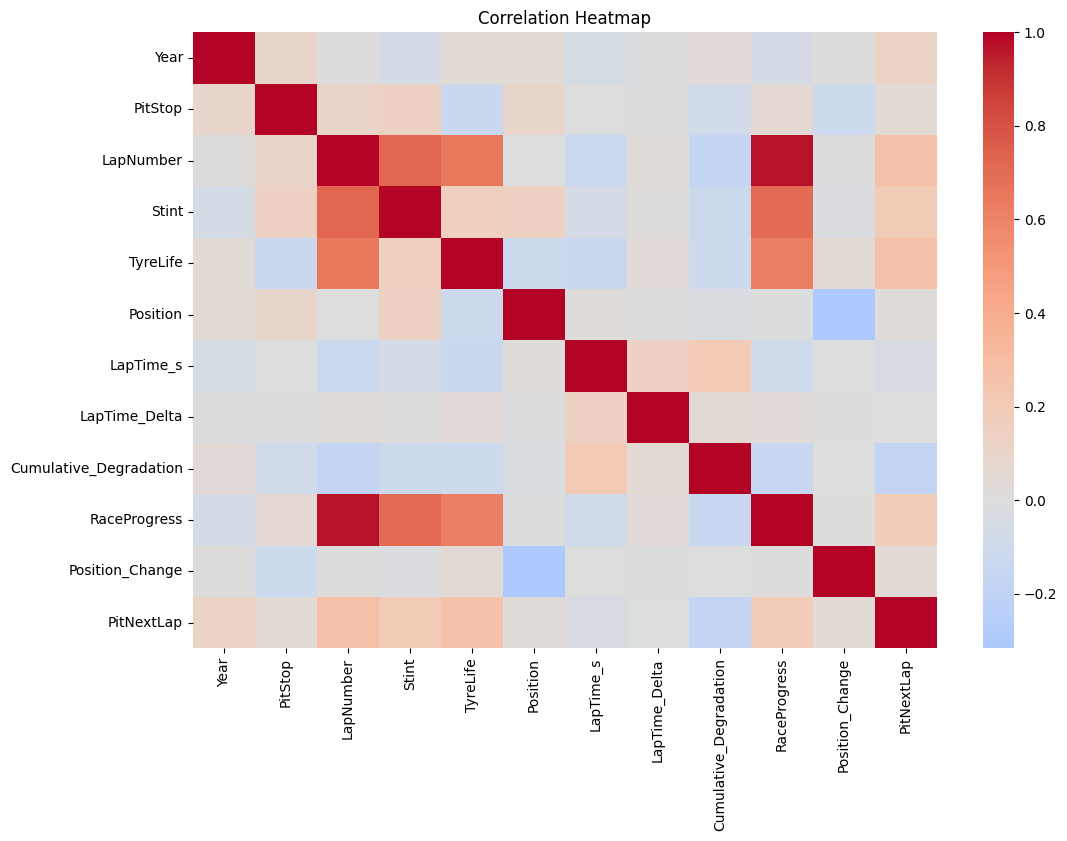

In [28]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    train_df[numerical_cols + [target]].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Observations

Tyre-related and race-timing features show the strongest relationship with `PitNextLap`.

`TyreLife`, `LapNumber`, `Stint`, and `RaceProgress` all show moderate positive correlation with the target, which aligns with expected Formula 1 strategy behavior.

Interestingly, `Cumulative_Degradation` shows a negative relationship with the target, suggesting that the degradation metric may represent performance loss differently than expected or may interact with other race conditions.

Features such as `Position` and `LapTime_Delta` appear to have relatively weak linear relationships with the target, although they may still contribute useful non-linear patterns in tree-based models.

### Key Takeaways

Several important patterns emerged during the exploratory analysis:

- Tire usage and race timing features appear to be the strongest predictors of pit stop behavior.
- The probability of pitting generally increases as tyre life and lap number increase.
- The dataset contains both real and synthetic driver identifiers.
- Timing-related features contain some extreme values that may represent unusual race events.
- The target variable is moderately imbalanced, so multiple evaluation metrics will be needed during modeling.
- Some features may introduce leakage risk and should be reviewed carefully in the next phase of the project.

## ⚙️ Feature Engineering and Preprocessing

In [29]:
# Display columns
train_df.columns.tolist()

['id',
 'Driver',
 'Compound',
 'Race',
 'Year',
 'PitStop',
 'LapNumber',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime_s',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change',
 'PitNextLap',
 'RaceProgress_Bin']

In [30]:
# Define feature columns
feature_cols = [
    "Driver",
    "Compound",
    "Race",
    "Year",
    "LapNumber",
    "Stint",
    "TyreLife",
    "Position",
    "LapTime_s",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change"
]

target = "PitNextLap"

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 13
['Driver', 'Compound', 'Race', 'Year', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


The `PitStop` feature was excluded from modeling features during the initial setup.

Because the target variable predicts whether a driver will pit on the next lap, the `PitStop` column may contain information that is too closely related to the target event itself. Excluding it helps reduce the risk of leakage and encourages the model to learn broader race and tire strategy patterns instead.

In [31]:
# Remove temporary EDA feature
train_df.drop(columns=["RaceProgress_Bin"], inplace=True)

print("Temporary EDA columns removed.")

Temporary EDA columns removed.


In [32]:
# Create X and y
X = train_df[feature_cols]
y = train_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (439140, 13)
Target shape: (439140,)


In [33]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Driver', 'Compound', 'Race']

Numerical features:
['Year', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


In [34]:
# Train-validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_valid distribution:")
print(y_valid.value_counts(normalize=True))

X_train shape: (351312, 13)
X_valid shape: (87828, 13)

y_train distribution:
PitNextLap
0.0    0.801017
1.0    0.198983
Name: proportion, dtype: float64

y_valid distribution:
PitNextLap
0.0    0.80102
1.0    0.19898
Name: proportion, dtype: float64


In [35]:
# Preprocessing and pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

In [36]:
# Preprocessing pipeline

# Scale numerical features
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# One-hot encode categorical features
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

### Preprocessing Summary

The dataset has now been prepared for machine learning workflows.

Key preparation steps completed include:

- Reviewing potential leakage risks
- Selecting modeling features
- Separating features and target variables
- Creating train and validation datasets
- Preserving class balance using stratified splitting
- Building preprocessing pipelines for numerical and categorical variables

The preprocessing pipeline created here can now be reused consistently across multiple machine learning models in the next stage of the project.

## 🤖 Model Training and Evaluation

In [37]:
# Modeling
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

### Evaluation Function

To compare models consistently, a reusable evaluation function is created.

Because the target variable is imbalanced, the evaluation focuses on multiple metrics instead of accuracy alone.

In [38]:
# Create evaluation function
def evaluate_model(model_name, model, X_valid, y_valid):
    """
    Evaluate a trained classification model on the validation set.
    """

    y_pred = model.predict(X_valid)

    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
    else:
        y_pred_proba = y_pred

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1": f1_score(y_valid, y_pred),
        "ROC_AUC": roc_auc_score(y_valid, y_pred_proba)
    }

    print(f"{model_name} Performance")
    print("-" * 40)
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")
    print(f"F1-Score : {metrics['F1']:.4f}")
    print(f"ROC-AUC  : {metrics['ROC_AUC']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_valid, y_pred))

    return metrics

In [39]:
# Create results list
model_results = []

### Baseline Model: Dummy Classifier

A Dummy Classifier is used as the baseline model.

This model does not learn meaningful patterns from the data. Instead, it makes simple predictions based on the target distribution.

The purpose of this baseline is to create a minimum performance benchmark. Any useful machine learning model should perform better than this baseline.

In [40]:
# Create a baseline model
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent",
                random_state=42
            )
        )
    ]
)

dummy_pipeline.fit(X_train, y_train)

dummy_results = evaluate_model(
    "Dummy Classifier",
    dummy_pipeline,
    X_valid,
    y_valid
)

model_results.append(dummy_results)

Dummy Classifier Performance
----------------------------------------
Accuracy : 0.8010
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
ROC-AUC  : 0.5000

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89     70352
         1.0       0.00      0.00      0.00     17476

    accuracy                           0.80     87828
   macro avg       0.40      0.50      0.44     87828
weighted avg       0.64      0.80      0.71     87828



### Dummy Classifier Evaluation

The Dummy Classifier predicts only the majority class (`0`), which represents drivers not pitting on the next lap.

Although the model achieves approximately 80% accuracy, this result is misleading because the dataset is imbalanced. The model completely fails to identify pit stop events, resulting in zero precision, recall, and F1-score for the positive class.

The ROC-AUC score of 0.50 confirms that the model performs no better than random guessing.

This baseline highlights why accuracy alone is not sufficient for evaluating this problem and establishes a minimum benchmark that meaningful machine learning models should outperform.

### Logistic Regression

In [41]:
# Logistic Regression pipeline
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [42]:
# Train Logistic Regression model
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'LapNumber', 'Stint',
                                                   'TyreLife', 'Position',
                                                   'LapTime_s', 'LapTime_Delta',
                                                   'Cumulative_Degradation',
                                                   'RaceProgress',
                                                   'Position_Change']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Driver', 'Compound',
                                                   'Race'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [43]:
# Evaluate Logistic Regression model
log_reg_results = evaluate_model(
    "Logistic Regression",
    log_reg_pipeline,
    X_valid,
    y_valid
)

model_results.append(log_reg_results)

Logistic Regression Performance
----------------------------------------
Accuracy : 0.8377
Precision: 0.6543
Recall   : 0.3912
F1-Score : 0.4897
ROC-AUC  : 0.8546

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90     70352
         1.0       0.65      0.39      0.49     17476

    accuracy                           0.84     87828
   macro avg       0.76      0.67      0.70     87828
weighted avg       0.82      0.84      0.82     87828



### Logistic Regression Evaluation

Logistic Regression performs significantly better than the Dummy Classifier across all evaluation metrics.

The model achieves a strong ROC-AUC score of approximately 0.85, suggesting that it is able to distinguish reasonably well between pit stop and non-pit stop situations.

Precision is notably higher than recall, which indicates that the model is relatively conservative when predicting pit stops. In other words, when the model predicts an upcoming pit stop, it is often correct, but it still misses a considerable number of actual pit stop events.

This behavior is common in imbalanced classification problems, where the model tends to favor the majority class. Despite this limitation, the results suggest that the dataset contains meaningful predictive signals related to race timing, tire usage, and strategy patterns.

### Random Forest Classifier

In [44]:
# Random Forest pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [45]:
# Train Random Forest model
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'LapNumber', 'Stint',
                                                   'TyreLife', 'Position',
                                                   'LapTime_s', 'LapTime_Delta',
                                                   'Cumulative_Degradation',
                                                   'RaceProgress',
                                                   'Position_Change']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Driver', 'Compound',
                                                   'Race'])])),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

In [46]:
# Evaluate Random Forest model
rf_results = evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_valid,
    y_valid
)

model_results.append(rf_results)

Random Forest Performance
----------------------------------------
Accuracy : 0.8912
Precision: 0.7635
Recall   : 0.6562
F1-Score : 0.7058
ROC-AUC  : 0.9393

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93     70352
         1.0       0.76      0.66      0.71     17476

    accuracy                           0.89     87828
   macro avg       0.84      0.80      0.82     87828
weighted avg       0.89      0.89      0.89     87828



### Random Forest Evaluation

Random Forest shows a substantial improvement over Logistic Regression across all evaluation metrics.

The model achieves approximately 89% accuracy and a ROC-AUC score above 0.93, indicating very strong class separation performance. Both precision and recall also improve considerably, resulting in a much stronger F1-score for the positive class.

Compared to Logistic Regression, Random Forest appears better able to capture the complex non-linear relationships involved in pit stop strategy decisions. This suggests that interactions between variables such as tyre life, lap timing, race progress, and stint information play an important role in prediction performance.

The improvement in recall is especially important because the model is now identifying a much larger proportion of actual pit stop events while still maintaining relatively strong precision.

### HistGradientBoosting Classifier

In [47]:
# Create dense preprocessing pipeline for HistGradientBoosting
hgb_categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            hgb_categorical_transformer,
            categorical_features
        )
    ]
)

In [48]:
# HistGradientBoosting pipeline
hgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

In [49]:
# Train HistGradientBoosting model
hgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'LapNumber', 'Stint',
                                                   'TyreLife', 'Position',
                                                   'LapTime_s', 'LapTime_Delta',
                                                   'Cumulative_Degradation',
                                                   'RaceProgress',
                                                   'Position_Change']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Driver', 'Compound',
                                                   'Race'])])),
                ('model', HistGradientBoostingClassifier(random_state=42))])

In [50]:
# Evaluate HistGradientBoosting model
hgb_results = evaluate_model(
    "HistGradientBoosting",
    hgb_pipeline,
    X_valid,
    y_valid
)

model_results.append(hgb_results)

HistGradientBoosting Performance
----------------------------------------
Accuracy : 0.8921
Precision: 0.7376
Recall   : 0.7108
F1-Score : 0.7239
ROC-AUC  : 0.9428

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93     70352
         1.0       0.74      0.71      0.72     17476

    accuracy                           0.89     87828
   macro avg       0.83      0.82      0.83     87828
weighted avg       0.89      0.89      0.89     87828



### HistGradientBoosting Evaluation

HistGradientBoosting achieves the strongest overall performance among the models tested so far.

The model slightly improves ROC-AUC and F1-score compared to Random Forest, while also achieving a better balance between precision and recall. In particular, recall improves further, meaning the model is able to identify a larger proportion of actual pit stop events.

These results suggest that boosting methods are especially effective for capturing the complex relationships involved in Formula 1 pit stop strategy decisions. Sequential tree boosting appears better suited to learning subtle interactions between tire wear, lap timing, race progression, and driver behavior.

Although Random Forest achieved slightly higher precision, HistGradientBoosting provides a more balanced classification performance overall, making it a strong candidate for further tuning and optimization.

A separate preprocessing pipeline was used for HistGradientBoosting because this model requires dense input data. The categorical variables were still one-hot encoded, but the encoded output was converted to a dense format before training.

## 🏁 Model Comparison

In [51]:
# Create model comparison table
results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Dummy Classifier,0.801020,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression,0.837740,0.654321,0.391222,0.489669,0.854626
2,Random Forest,0.891151,0.763515,0.656214,0.705810,0.939347
3,HistGradientBoosting,0.892130,0.737561,0.710803,0.723935,0.942756


In [52]:
# Sort models by ROC-AUC
results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,HistGradientBoosting,0.892130,0.737561,0.710803,0.723935,0.942756
2,Random Forest,0.891151,0.763515,0.656214,0.705810,0.939347
1,Logistic Regression,0.837740,0.654321,0.391222,0.489669,0.854626
0,Dummy Classifier,0.801020,0.000000,0.000000,0.000000,0.500000


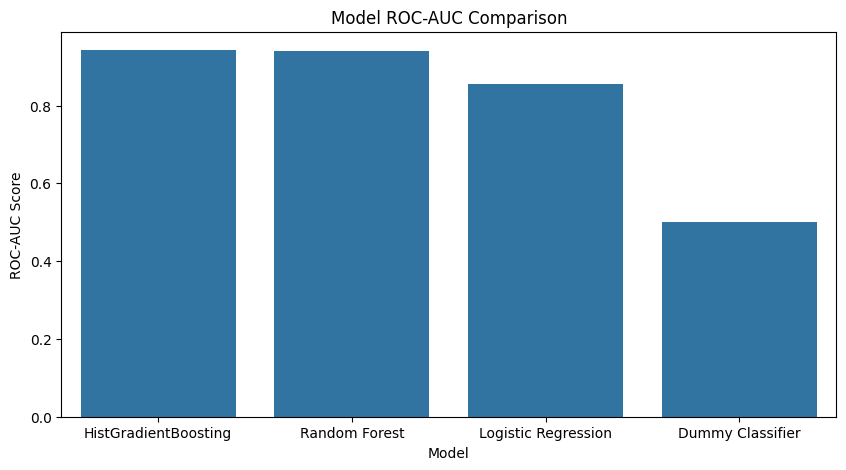

In [53]:
# Visualize model comparison
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df.sort_values(
        by="ROC_AUC",
        ascending=False
    ),
    x="Model",
    y="ROC_AUC"
)

plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC Score")

plt.show()

### Model Comparison Summary

The Dummy Classifier established a baseline performance benchmark, confirming that accuracy alone is not a reliable metric for this problem because of class imbalance.

Logistic Regression demonstrated that the dataset contains meaningful predictive patterns, achieving a strong ROC-AUC score while remaining relatively interpretable.

Both tree-based ensemble models substantially outperformed Logistic Regression, indicating that non-linear feature interactions play an important role in pit stop prediction.

Among the evaluated models, **HistGradientBoosting achieved the strongest overall balance between ROC-AUC, recall, and F1-score, making it the leading candidate** for further optimization in the next stage of the project.

## 🎯 Best Model Analysis

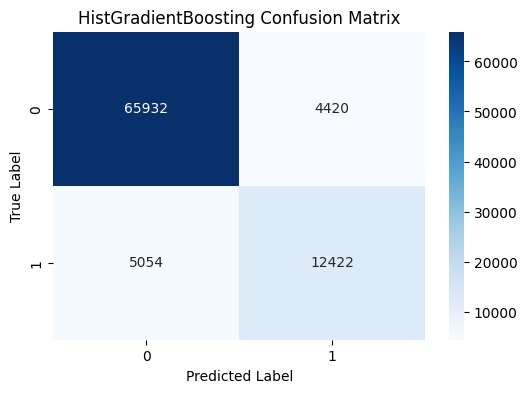

In [54]:
# HistGradientBoosting predictions
hgb_y_pred = hgb_pipeline.predict(X_valid)

# Confusion matrix
cm = confusion_matrix(y_valid, hgb_y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("HistGradientBoosting Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that HistGradientBoosting performs well across both classes while maintaining a relatively balanced trade-off between precision and recall.

The model correctly identifies a large number of pit stop events (`12,422` true positives) while keeping false positives relatively controlled.

Some pit stop events are still missed (`5,054` false negatives), which suggests that certain race situations remain difficult to predict accurately. However, the overall balance between missed pit stops and incorrect pit stop predictions is considerably better than earlier models.

This result reinforces that the boosting-based approach is effectively learning meaningful race strategy patterns from the available features.

## 📈 Feature Importance Analysis

In [55]:
# Feature importance
from sklearn.inspection import permutation_importance

In [56]:
# Calculate permutation importance
perm_importance = permutation_importance(
    hgb_pipeline,
    X_valid,
    y_valid,
    n_repeats=5,
    random_state=42,
    scoring="f1"
)

In [57]:
# Create feature importance dataframe
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": perm_importance.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
6,TyreLife,0.308146
5,Stint,0.294382
3,Year,0.135724
11,RaceProgress,0.073554
2,Race,0.040208
9,LapTime_Delta,0.025072
1,Compound,0.016936
12,Position_Change,0.005983
4,LapNumber,0.005754
8,LapTime_s,0.003855


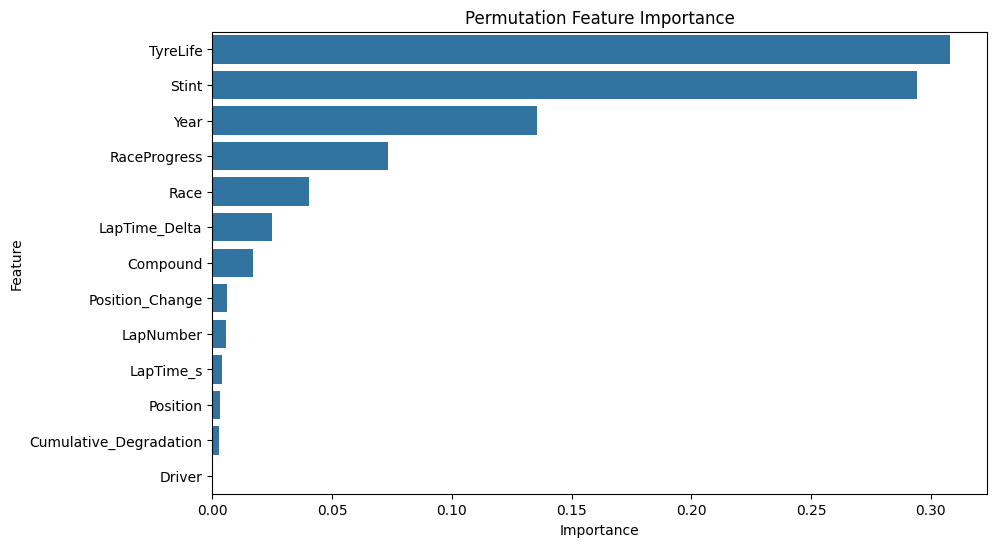

In [58]:
# Plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance Interpretation

The feature importance analysis shows that tire-related and race progression features are the strongest drivers of pit stop prediction.

`TyreLife` is the most important feature by a clear margin, which aligns closely with real Formula 1 race strategy. As tires age and performance declines, the likelihood of an upcoming pit stop increases significantly.

`Stint` also contributes heavily to prediction performance, suggesting that the stage of a tire cycle plays an important role in pit timing decisions. `RaceProgress` further reinforces the importance of race timing and strategy progression.

Interestingly, `Driver` contributes very little predictive importance despite containing many unique values. This suggests that pit stop behavior is influenced more strongly by race conditions and tire state than by driver identity alone.

`Year` also appears more influential than expected, which may indicate that race strategies, regulations, tire behavior, or dataset generation patterns differ across seasons.

Overall, the results suggest that pit stop prediction is driven primarily by tire management and race timing variables rather than isolated driver-specific effects.

### Key Takeaways

Several important findings emerged during the model evaluation process:

- Simple baseline models were insufficient for handling the class imbalance problem.
- Logistic Regression demonstrated that meaningful predictive signals exist within the dataset.
- Tree-based ensemble methods significantly improved overall predictive performance.
- HistGradientBoosting achieved the strongest balance between precision and recall.
- Tire-related features such as `TyreLife` and `Stint` were the most influential variables in prediction performance.
- Driver identity contributed relatively little importance compared to race timing and tire management features.

The next stage of the project will focus on hyperparameter tuning, threshold optimization, and additional performance improvements for the selected model.